This project analyzes trends in PM2.5(fine particulate matter) air pollution in the United States using environmental health data.The goal of this analysis is to examine how PM2.5 levels have changed over time.

In [1]:
import pandas as pd 
import numpy as np

In [2]:
raw_data = pd.read_csv("Air_Quality_Data.csv")

In [3]:
raw_data = raw_data.copy()

In [4]:
raw_data

,MeasureId,MeasureName,MeasureType,StratificationLevel,StateFips,StateName,CountyFips,CountyName,ReportYear,Value,Unit,UnitName,DataOrigin,MonitorOnly
0,83,Number of days with maximum 8-hour average ozo...,Counts,State x County,1,Alabama,1027,Clay,1999,33.000000,No Units,No Units,Monitor Only,1
1,83,Number of days with maximum 8-hour average ozo...,Counts,State x County,1,Alabama,1051,Elmore,1999,5.000000,No Units,No Units,Monitor Only,1
2,83,Number of days with maximum 8-hour average ozo...,Counts,State x County,1,Alabama,1073,Jefferson,1999,39.000000,No Units,No Units,Monitor Only,1
3,83,Number of days with maximum 8-hour average ozo...,Counts,State x County,1,Alabama,1079,Lawrence,1999,28.000000,No Units,No Units,Monitor Only,1
4,83,Number of days with maximum 8-hour average ozo...,Counts,State x County,1,Alabama,1089,Madison,1999,31.000000,No Units,No Units,Monitor Only,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
218630,296,Annual average ambient concentrations of PM 2....,Average,State x County,56,Wyoming,56045,Weston,2007,6.207126,µg/m³,Micograms per cubic meter,Monitor & Modeled,0
218631,296,Annual average ambient concentrations of PM 2....,Average,State x County,56,Wyoming,56045,Weston,2008,6.369764,µg/m³,Micograms per cubic meter,Monitor & Modeled,0
218632,296,Annual average ambient concentrations of PM 2....,Average,State x County,56,Wyoming,56045,Weston,2009,6.241708,µg/m³,Micograms per cubic meter,Monitor & Modeled,0
218633,296,Annual average ambient concentrations of PM 2....,Average,State x County,56,Wyoming,56045,Weston,2010,6.125957,µg/m³,Micograms per cubic meter,Monitor & Modeled,0


In [5]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 218635 entries, 0 to 218634
Data columns (total 14 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   MeasureId            218635 non-null  int64  
 1   MeasureName          218635 non-null  object 
 2   MeasureType          218635 non-null  object 
 3   StratificationLevel  218635 non-null  object 
 4   StateFips            218635 non-null  int64  
 5   StateName            218635 non-null  object 
 6   CountyFips           218635 non-null  int64  
 7   CountyName           218635 non-null  object 
 8   ReportYear           218635 non-null  int64  
 9   Value                218635 non-null  float64
 10  Unit                 218635 non-null  object 
 11  UnitName             218635 non-null  object 
 12  DataOrigin           218635 non-null  object 
 13  MonitorOnly          218635 non-null  int64  
dtypes: float64(1), int64(5), object(8)
memory usage: 23.4+ MB


lots of columns that don't really hold information we need

In [6]:
columns_to_drop = ["MeasureId", "StateFips", "CountyFips", "DataOrigin", "UnitName"]
data = raw_data.drop(columns = columns_to_drop)

In [7]:
data.head()

,MeasureName,MeasureType,StratificationLevel,StateName,CountyName,ReportYear,Value,Unit,MonitorOnly
0,Number of days with maximum 8-hour average ozo...,Counts,State x County,Alabama,Clay,1999,33.0,No Units,1
1,Number of days with maximum 8-hour average ozo...,Counts,State x County,Alabama,Elmore,1999,5.0,No Units,1
2,Number of days with maximum 8-hour average ozo...,Counts,State x County,Alabama,Jefferson,1999,39.0,No Units,1
3,Number of days with maximum 8-hour average ozo...,Counts,State x County,Alabama,Lawrence,1999,28.0,No Units,1
4,Number of days with maximum 8-hour average ozo...,Counts,State x County,Alabama,Madison,1999,31.0,No Units,1


In [8]:
data["MeasureName"].unique()

array(['Number of days with maximum 8-hour average ozone concentration over the National Ambient Air Quality Standard',
       'Percent of days with PM2.5 levels over the National Ambient Air Quality Standard (NAAQS)',
       'Person-days with PM2.5 over the National Ambient Air Quality Standard',
       'Number of person-days with maximum 8-hour average ozone concentration over the National Ambient Air Quality Standard',
       'Annual average ambient concentrations of PM2.5 in micrograms per cubic meter (based on seasonal averages and daily measurement)',
       'Number of days with maximum 8-hour average ozone concentration over the National Ambient Air Quality Standard (monitor and modeled data)',
       'Number of person-days with maximum 8-hour average ozone concentration over the National Ambient Air Quality Standard (monitor and modeled data)',
       'Percent of days with PM2.5 levels over the National Ambient Air Quality Standard (monitor and modeled data)',
       'Number of

In [9]:
data.shape

(218635, 9)

since there's multiple MeasureName values, we'll focus on average annual concentration of pm2.5 by filtering out the other MeasureName types

In [10]:
pm25 = data[data["MeasureName"].str.contains("Annual average ambient concentrations of PM2.5", na=False)]
pm25 = pm25.sort_values(by = "ReportYear")
pm25

,MeasureName,MeasureType,StratificationLevel,StateName,CountyName,ReportYear,Value,Unit,MonitorOnly
44930,Annual average ambient concentrations of PM2.5...,Average,State x County,Massachusetts,Hampden,1999,15.459769,µg/m³,1
40152,Annual average ambient concentrations of PM2.5...,Average,State x County,New Hampshire,Merrimack,1999,10.799755,µg/m³,1
44060,Annual average ambient concentrations of PM2.5...,Average,State x County,California,Riverside,1999,30.201011,µg/m³,1
42783,Annual average ambient concentrations of PM2.5...,Average,State x County,Arizona,Pima,1999,9.660785,µg/m³,1
46810,Annual average ambient concentrations of PM2.5...,Average,State x County,Alabama,Mobile,1999,19.408193,µg/m³,1
...,...,...,...,...,...,...,...,...,...
42706,Annual average ambient concentrations of PM2.5...,Average,State x County,West Virginia,Marion,2013,9.338522,µg/m³,1
46751,Annual average ambient concentrations of PM2.5...,Average,State x County,Virginia,Virginia Beach,2013,7.738379,µg/m³,1
43670,Annual average ambient concentrations of PM2.5...,Average,State x County,Indiana,Greene,2013,9.783984,µg/m³,1
40389,Annual average ambient concentrations of PM2.5...,Average,State x County,Arizona,Pinal,2013,14.846254,µg/m³,1


In [11]:
# find average concetration per year 
pm25_annual = pm25.groupby("ReportYear")["Value"].mean()
pm25_annual

ReportYear
1999    13.748994
2000    13.020075
2001    12.403782
2002    11.956124
2003    11.808624
2004    11.550947
2005    12.607519
2006    11.432796
2007    11.772843
2008    10.688418
2009     9.528830
2010     9.790810
2011     9.672332
2012     9.063382
2013     8.821925
Name: Value, dtype: float64

In [24]:
pm25_annual = pm25.groupby(["ReportYear"])["Value"].mean().reset_index()

In [25]:
print(pm25_annual)

    ReportYear      Value
0         1999  13.748994
1         2000  13.020075
2         2001  12.403782
3         2002  11.956124
4         2003  11.808624
5         2004  11.550947
6         2005  12.607519
7         2006  11.432796
8         2007  11.772843
9         2008  10.688418
10        2009   9.528830
11        2010   9.790810
12        2011   9.672332
13        2012   9.063382
14        2013   8.821925


In [26]:
#visualize pm25 dataframe
import matplotlib.pyplot as plt
import seaborn as sns

In [43]:
pm25

,MeasureName,MeasureType,StratificationLevel,StateName,CountyName,ReportYear,Value,Unit,MonitorOnly
44930,Annual average ambient concentrations of PM2.5...,Average,State x County,Massachusetts,Hampden,1999,15.459769,µg/m³,1
40152,Annual average ambient concentrations of PM2.5...,Average,State x County,New Hampshire,Merrimack,1999,10.799755,µg/m³,1
44060,Annual average ambient concentrations of PM2.5...,Average,State x County,California,Riverside,1999,30.201011,µg/m³,1
42783,Annual average ambient concentrations of PM2.5...,Average,State x County,Arizona,Pima,1999,9.660785,µg/m³,1
46810,Annual average ambient concentrations of PM2.5...,Average,State x County,Alabama,Mobile,1999,19.408193,µg/m³,1
...,...,...,...,...,...,...,...,...,...
42706,Annual average ambient concentrations of PM2.5...,Average,State x County,West Virginia,Marion,2013,9.338522,µg/m³,1
46751,Annual average ambient concentrations of PM2.5...,Average,State x County,Virginia,Virginia Beach,2013,7.738379,µg/m³,1
43670,Annual average ambient concentrations of PM2.5...,Average,State x County,Indiana,Greene,2013,9.783984,µg/m³,1
40389,Annual average ambient concentrations of PM2.5...,Average,State x County,Arizona,Pinal,2013,14.846254,µg/m³,1


In [45]:
pm25_annual = pm25.groupby("ReportYear")["Value"].mean().reset_index()
pm25_annual

,ReportYear,Value
0,1999,13.748994
1,2000,13.020075
2,2001,12.403782
3,2002,11.956124
4,2003,11.808624
5,2004,11.550947
6,2005,12.607519
7,2006,11.432796
8,2007,11.772843
9,2008,10.688418


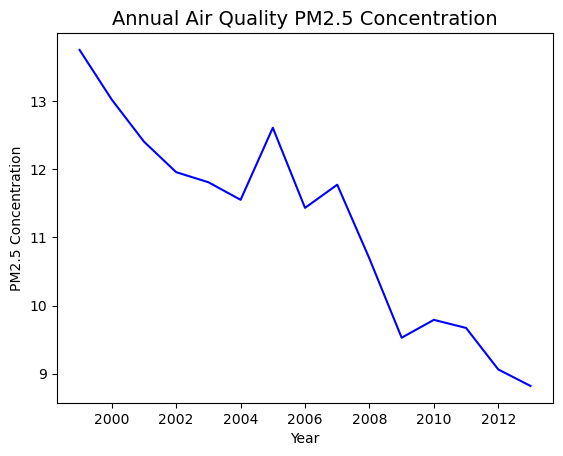

In [46]:
plt.plot(pm25_annual["ReportYear"], pm25_annual["Value"] , color = 'blue')
plt.title("Annual Air Quality PM2.5 Concentration", fontsize = 14)
plt.ylabel("PM2.5 Concentration")
plt.xlabel("Year")
plt.show()

This line chart sows the average annual concentration of PM2.5 over the years. identifying a descreasing trend 

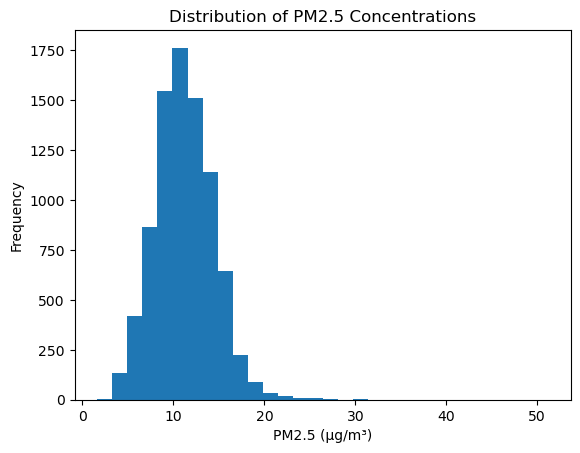

In [49]:
pm25["Value"].plot(kind="hist", bins=30)

plt.title("Distribution of PM2.5 Concentrations")
plt.xlabel("PM2.5 (µg/m³)")

plt.show()

This histogram shows the distribution of pm2.5 measurements. most measurements fall between 10 ans a little higher.

The decreasing average of PM2.5 concentration over the years and the lower overall distribution of frequency can imply gradual improvements. Could possibly look into state-wide differences or the other measurement types.